# leafwaxtools Tutorial: Chain API class

This tutorial walks through using each function in the Chain API class using a real, published leaf wax dataset. It also provides example code for producing figures using the results of each leafwaxtools function. For additional information, please see the documentation website for leafwaxtools: https://leafwax-tools.readthedocs.io/en/latest/

Import the leafwaxtools Chain module/class and other necessary packages for this tutorial. It's recommended to use the leafwaxtools conda environment (environment.yml) provided in the GitHub repository which contains all of the packages you'll need for this notebook. See the documentation for more details on installing the leafwaxtools conda environment: https://leafwax-tools.readthedocs.io/en/latest/installation.html

In [2]:
from leafwaxtools import Chain

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Leaf Wax Data

First, we'll need to prepare some leaf wax carbon chain-length distribution data to use with the leafwaxtools Chain class. For this tutorial, we'll use this dataset (https://doi.org/10.25921/r1dc-8930) from Thomas et al. (2023). It contains leaf wax *n*-alkanoic acid data and branched glycerol dialkyl glycerol tetraether (brGDGT) data from Early Holocene lake sediment samples from Lake CF8, Baffin Island, Nunavut, Canada (70.56 N, 68.95 W).

Thomas, E. K., Cluett, A. A., Erb, M. P., McKay, N. P., Briner, J. P., Castañeda, I. S., ... & Salacup, J. (2023). Early Holocene Laurentide ice sheet retreat influenced summer atmospheric circulation in Baffin Bay. Geophysical Research Letters, 50(13), e2023GL103428. https://doi.org/10.1029/2023GL103428

In [3]:
cf8sed_data_df = pd.read_csv(r'../leafwaxtools/data/Thomas_CF8_2023.csv')

# In this dataset, some samples (rows) do not contain any leaf wax chain-length data (expressed as "NaN"), so we remove them after importing the original .csv file.
cf8sed_data_df.dropna(
    subset=[
        'peakAreaC20FattyAcidMethylEster',
        'peakAreaC21FattyAcidMethylEster',
        'peakAreaC22FattyAcidMethylEster',
        'peakAreaC23FattyAcidMethylEster',
        'peakAreaC24FattyAcidMethylEster',
        'peakAreaC25FattyAcidMethylEster',
        'peakAreaC26FattyAcidMethylEster',
        'peakAreaC27FattyAcidMethylEster',
        'peakAreaC28FattyAcidMethylEster',
        'peakAreaC29FattyAcidMethylEster',
        'peakAreaC30FattyAcidMethylEster',
        'peakAreaC31FattyAcidMethylEster',
        'peakAreaC32FattyAcidMethylEster',
    ], inplace=True
)
cf8sed_data_df.reset_index(drop=True, inplace=True)

cf8sed_data_df



,CoreName,MidpointDepth,TopDepth,Thickness,SamplingID,UBlabID,SamplingNotesAboutSedimentology,AquaticMossMacrofossilAbundance,MassDrySediment,MassTotalLipidExtract,...,FAbrGDGTIIa',FAbrGDGTIIb,FAbrGDGTIIb',FAbrGDGTIIc,FAbrGDGTIIc',FAbrGDGTIa,FAbrGDGTIb,FAbrGDGTIc,ZhaoIWT,ageMedian
0,07CF8L4,0.25,0.0,0.5,EKT249,EKT249,no large aquatic moss macrofossils (none even ...,0,1.042,4.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7522.741
1,07CF8L4,0.75,0.5,0.5,EKT248,EKT248,no large aquatic moss macrofossils (none even ...,0,0.965,3.83,...,0.062,0.034,0.005,0.001,0.0,0.138,0.022,0.001,8.189462,7545.194
2,07CF8L4,1.25,1.0,0.5,EKT247,EKT247,no large aquatic moss macrofossils (none even ...,0,0.927,3.30,...,0.065,0.033,0.004,0.001,0.0,0.137,0.021,0.001,8.044775,7564.971
3,07CF8L4,1.75,1.5,0.5,EKT246,EKT246,no large aquatic moss macrofossils (none even ...,0,0.902,3.10,...,0.060,0.033,0.004,0.001,0.0,0.141,0.023,0.001,8.325403,7594.084
4,07CF8L4,2.25,2.0,0.5,EKT245,EKT245,no large aquatic moss macrofossils (none even ...,0,0.955,3.31,...,0.069,0.029,0.005,0.001,0.0,0.145,0.025,0.001,8.853391,7621.021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,07CF8L4,68.25,68.0,0.5,EKT113,EKT113,lots of aquatic moss macrofossils (hard to sam...,6,0.790,NaN,...,0.053,0.007,0.000,0.000,0.0,0.110,0.006,0.000,5.267715,10837.010
91,07CF8L4,77.25,77.0,0.5,EKT095,EKT095,aquatic moss macrofossils,2,1.817,NaN,...,0.037,0.006,0.000,0.001,0.0,0.119,0.004,0.000,5.504847,11834.990
92,07CF8L4,77.75,77.5,0.5,EKT094,EKT094,aquatic moss macrofossils,2,1.167,NaN,...,0.039,0.005,0.000,0.000,0.0,0.111,0.003,0.000,5.064226,11894.530
93,07CF8L4,78.25,78.0,0.5,EKT093,EKT093,aquatic moss macrofossils,2,1.149,NaN,...,0.046,0.003,0.000,0.000,0.0,0.117,0.002,0.000,5.330160,11959.460


## Preparing Leaf Wax Carbon Chain-Length Distribution Data

The functions in the leafwaxtools Chain class only require the chain-length data itself, and assumes that the data are organized where each row is a sample and each column is a carbon chain-length. Here, we isolate the chain-length data (C$_{20}$-C$_{32}$) from the full dataset (containing metadata, leaf wax hydrogen isotopes, and brGDGTs) to use with leafwaxtools.

Some functions in the Chain class (acl, cpi, pca) require the user to provide information about the carbon chain-length numbers of each data column. Here, we define a quick function, get_chain_lengths(), to extract the carbon chain-length number from the DataFrame column names. Users can also just provide a list of integers when calling the function (i.e. chain_lengths=[22,24,26,28]).

In [ ]:
# All n-alkanoic acid carbon chain-lengths
cf8sed_nacid_chain_df = cf8sed_data_df[
    [
        'peakAreaC20FattyAcidMethylEster',
        'peakAreaC21FattyAcidMethylEster',
        'peakAreaC22FattyAcidMethylEster',
        'peakAreaC23FattyAcidMethylEster',
        'peakAreaC24FattyAcidMethylEster',
        'peakAreaC25FattyAcidMethylEster',
        'peakAreaC26FattyAcidMethylEster',
        'peakAreaC27FattyAcidMethylEster',
        'peakAreaC28FattyAcidMethylEster',
        'peakAreaC29FattyAcidMethylEster',
        'peakAreaC30FattyAcidMethylEster',
        'peakAreaC31FattyAcidMethylEster',
        'peakAreaC32FattyAcidMethylEster',
    ]
]

# Only even-chain n-alkanoic acid carbon chain-lengths
cf8sed_nacid_evenchain_df = cf8sed_nacid_chain_df[
    [
        'peakAreaC20FattyAcidMethylEster',
        'peakAreaC22FattyAcidMethylEster',
        'peakAreaC24FattyAcidMethylEster',
        'peakAreaC26FattyAcidMethylEster',
        'peakAreaC28FattyAcidMethylEster',
        'peakAreaC30FattyAcidMethylEster',
        'peakAreaC32FattyAcidMethylEster',
    ]
]


# Function to create a list of carbon chain-length numbers from the DataFrame column headers
def get_chain_lengths(df_columns):
    chain_lengths_num = [None] * len(df_columns)
    chain_lengths_str = [None] * len(df_columns)
    for i in range(len(df_columns)):
        column_name = df_columns[i]
        chain_lengths_num[i] = int(column_name[9:11])
        chain_lengths_str[i] = "C" + str(chain_lengths_num[i])

    return chain_lengths_num, chain_lengths_str


cf8_chain_lengths, cf8_chain_lengths_str = get_chain_lengths(cf8sed_nacid_chain_df.columns)
cf8_evenchain_lengths, cf8_evenchain_lengths_str = get_chain_lengths(cf8sed_nacid_evenchain_df.columns)

print(cf8_chain_lengths)
print(cf8_chain_lengths_str)


[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
['C20', 'C21', 'C22', 'C23', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30', 'C31', 'C32']


## Total Concentration: Chain.total_conc()

This function calculates the total leaf wax concentration of each sample (row). In this dataset, chain-length abundances are reported as chromatograph peak areas (pA*min).

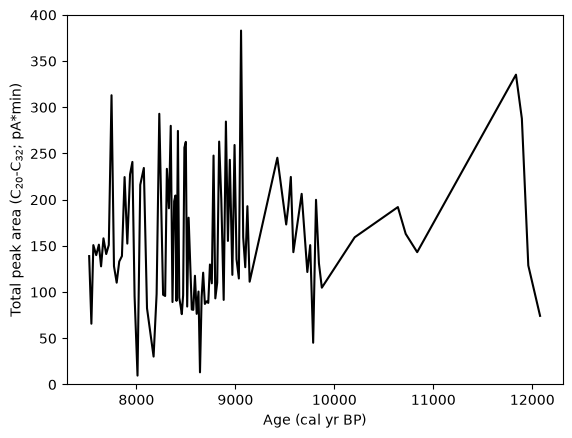

In [ ]:
# Initialize the Chain object and calling the total_conc() function in the same line...
cf8sed_nacid_chain_total_conc = Chain(cf8sed_nacid_chain_df).total_conc()

# Alternatively, initializing the Chain object first, then calling the total_conc() function later on
cf8sed_nacid_chain_obj = Chain(cf8sed_nacid_chain_df)
cf8sed_nacid_chain_total_conc = cf8sed_nacid_chain_obj.total_conc()


fig, ax = plt.subplots()
ax.plot(cf8sed_data_df.ageMedian, cf8sed_nacid_chain_total_conc, color='black')
ax.set_xlabel("Age (cal yr BP)")
ax.set_ylabel("Total peak area (C$_{20}$-C$_{32}$; pA*min)")
ax.set_ylim([0,400])

plt.show()

## Chain-Length Relative Abundance: Chain.relative_abd()

This function calculates the relative abundance (from 0 to 1) of each leaf wax chain-length.

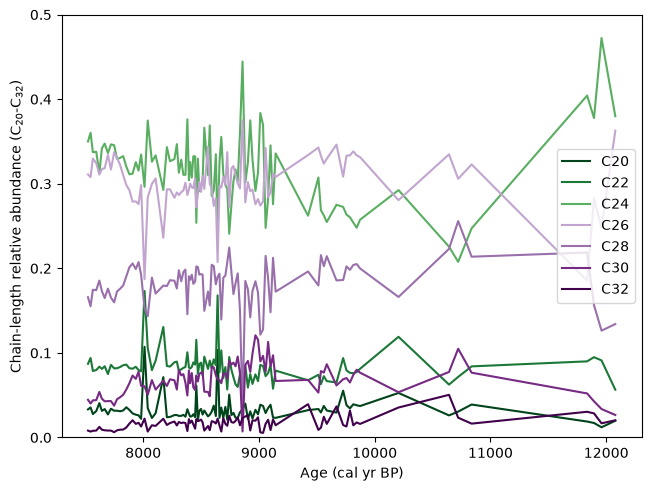

In [18]:
cf8sed_nacid_chain_relative_abd = Chain(cf8sed_nacid_evenchain_df).relative_abd()


colors = [
    '#00441b',
    '#1b7837',
    '#5aae61',
    '#c2a5cf',
    '#9970ab',
    '#762a83',
    '#40004b'
]

fig, ax = plt.subplots(layout='constrained')
for i in range(len(colors)):
    ax.plot(
        cf8sed_data_df.ageMedian, cf8sed_nacid_chain_relative_abd[:,i], 
        color=colors[i], zorder=i, label=cf8_evenchain_lengths_str[i]
    )
ax.set_ylim([0,0.5])
ax.set_xlabel("Age (cal yr BP)")
ax.set_ylabel(u"Chain-length relative abundance (C$_{20}$-C$_{32}$)")
ax.legend()

plt.show()

## Average Chain-Length: Chain.acl()

This function calculates the Average Chain-Length (ACL) of each sample..

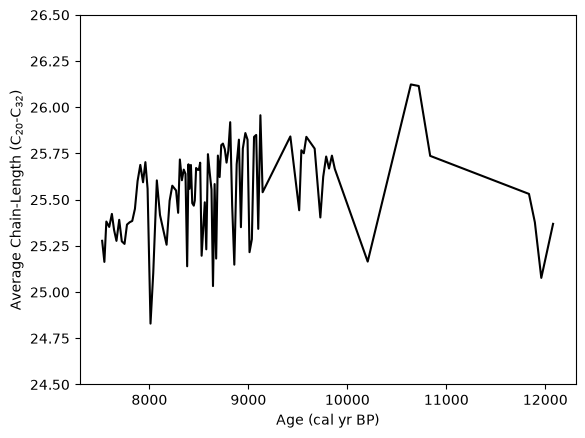

In [19]:
cf8sed_nacid_chain_acl = Chain(cf8sed_nacid_chain_df).acl(chain_lengths=cf8_chain_lengths)


fig, ax = plt.subplots()
ax.plot(cf8sed_data_df.ageMedian, cf8sed_nacid_chain_acl, color='black')
ax.set_xlabel("Age (cal yr BP)")
ax.set_ylabel(u"Average Chain-Length (C$_{20}$-C$_{32}$)")
ax.set_ylim([24.5,26.5])

plt.show()

## Carbon Preference Index: Chain.cpi()

This function calculates the Carbon Preference Index (CPI) of each sample. Since we are working with leaf wax *n*-alkanoic acids which are even-chain dominant, we use the default setting of even_over_odd=True. This setting calculates the CPI of even chain-lengths over odd chain-lengths. When working with leaf wax *n*-alkanes, set even_over_odd=False to calculate the CPI of odd chain-lengths over even chain-lengths.

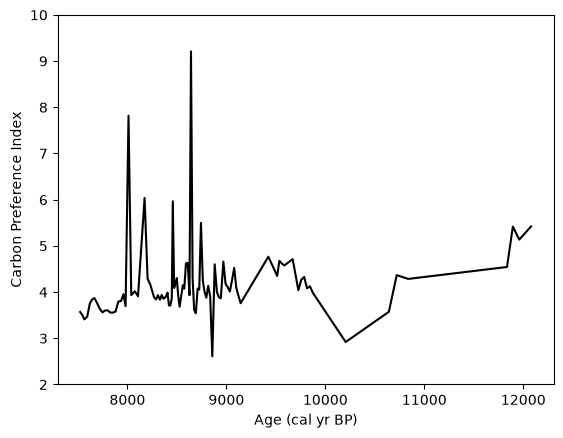

In [ ]:
cf8sed_nacid_chain_cpi = Chain(cf8sed_nacid_chain_df).cpi(chain_lengths=cf8_chain_lengths, even_over_odd=True)


fig, ax = plt.subplots()
ax.plot(cf8sed_data_df.ageMedian, cf8sed_nacid_chain_cpi, color='black')
ax.set_xlabel("Age (cal yr BP)")
ax.set_ylabel("Carbon Preference Index")
ax.set_ylim([2,10])

plt.show()

## Correlation Matrices: Chain.correlation_rvals() & Chain.correlation_pvals()

These two functions each create a matrix/2-D array (# of chain-lengths $\times$ # of chain-lengths) of Pearson *r*- and *p*-values between all pairs of chain-lengths using all samples.

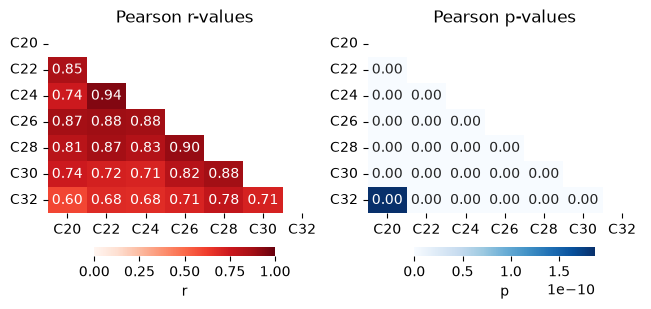

In [9]:
cf8sed_nacid_chain_correlation_rvals = Chain(cf8sed_nacid_evenchain_df).correlation_rvals()
cf8sed_nacid_chain_correlation_pvals = Chain(cf8sed_nacid_evenchain_df).correlation_pvals()


fig, axs = plt.subplots(2,2,layout='constrained')

corr_mask = np.triu(np.ones_like(cf8sed_nacid_chain_correlation_rvals, dtype=bool))

ax = axs[0,0]
ax.set_title("Pearson r-values")
sns.heatmap(
    ax=ax, data=cf8sed_nacid_chain_correlation_rvals,
    cmap='Reds', mask=corr_mask, annot=True, fmt='.2f', vmin=0, vmax=1,
    linewidths=0, linecolor='black', clip_on=False,
    cbar=True, cbar_kws={'label': "r", 'shrink': 0.66, 'location': 'bottom'},
    xticklabels=cf8_evenchain_lengths_str,
    yticklabels=cf8_evenchain_lengths_str
)

ax = axs[0,1]
ax.set_title("Pearson p-values")
sns.heatmap(
    ax=ax, data=cf8sed_nacid_chain_correlation_pvals,
    cmap='Blues', mask=corr_mask, annot=True, fmt='.2f',
    linewidths=0, linecolor='black', clip_on=False,
    cbar=True, cbar_kws={'label': "p", 'shrink': 0.66, 'location': 'bottom'},
    xticklabels=cf8_evenchain_lengths_str,
    yticklabels=cf8_evenchain_lengths_str
)

fig.delaxes(axs[1,0])
fig.delaxes(axs[1,1])

plt.show()

## Principal Component Analysis: Chain.pca()

This function performs a Principal Component Analysis (PCA) on the user chain-length data. By default, this function performs a Centered Log-Ratio (CLR) transformation on the leaf wax data prior to PCA (scaling_method='clr'). This can be changed by setting scaling_method=None (no data scaling, not recommended) or scaling_method='z-score' (subtract the data mean and divide by data variance).

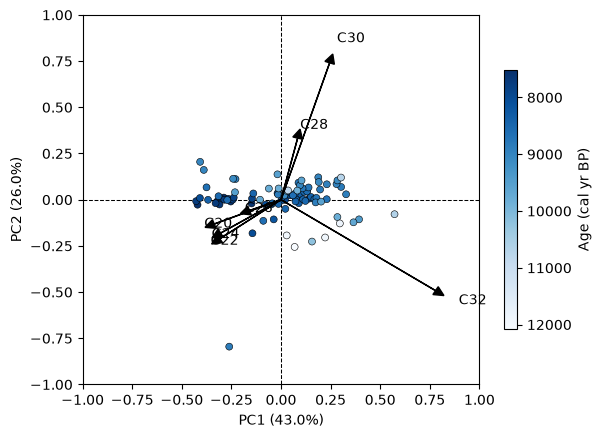

In [ ]:
cf8sed_nacid_evenchain_pca = Chain(cf8sed_nacid_evenchain_df).pca(
    chain_lengths=cf8_evenchain_lengths_str,
    scaling_method='clr'
)


fig, ax = plt.subplots()

# Plot loading vectors (leaf wax chain-length variables) 
for i, feature in enumerate(cf8sed_nacid_evenchain_pca["features"]):
    ax.arrow(
        0, 0, cf8sed_nacid_evenchain_pca["loadings"].iloc[i,0], cf8sed_nacid_evenchain_pca["loadings"].iloc[i,1],
        head_width=0.05, head_length=0.05, color='black', zorder=15
    )
    ax.text(
        cf8sed_nacid_evenchain_pca["loadings"].iloc[i,0] * 1.15, cf8sed_nacid_evenchain_pca["loadings"].iloc[i,1] * 1.15,
        str(feature), fontsize=10, zorder=15
    )

# Plot sample principal component scores
sns.scatterplot(
    ax=ax, x=cf8sed_nacid_evenchain_pca["scores_scaled"].PC1, y=cf8sed_nacid_evenchain_pca["scores_scaled"].PC2,
    s=25, hue=cf8sed_data_df.ageMedian, palette='Blues_r', edgecolors='black', zorder=10
)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.75, zorder=5)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.75, zorder=5)
ax.set_xlabel("PC1 (" + str(np.round(cf8sed_nacid_evenchain_pca["pca"].explained_variance_ratio_[0]*100, decimals=0)) + "%)")
ax.set_ylabel("PC2 (" + str(np.round(cf8sed_nacid_evenchain_pca["pca"].explained_variance_ratio_[1]*100, decimals=0)) + "%)")
ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.legend('', frameon=False)

norm = plt.Normalize(cf8sed_data_df['ageMedian'].min(), cf8sed_data_df['ageMedian'].max())
sm = plt.cm.ScalarMappable(cmap='Blues_r', norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, ax=ax,
    location='right', shrink=0.7, label="Age (cal yr BP)",
).ax.invert_yaxis()

plt.show()

## PCA with Supplemental Individuals

As of leafwaxtools version 3.2.0, the Chain.pca() function now supports PCA with supplemental individuals; samples which are assigned scores for each principal component based on the PCA of the active samples, but which do not affect the PCA results themselves.

Here, we import an additional dataset (https://doi.org/10.18739/A20P0WS80) of leaf waxes from terrestrial plants across the Arctic, including some collected from the Lake CF8 catchment. We now treat the plant samples from Lake CF8 as the active samples for PCA and use the sediment samples as our supplemental individuals (supp_inds=cf8sed_nacid_evenchain_df).  

Lindberg, K. R., Thomas, E. K., Raynolds, M. K., Bültmann, H., & Raberg, J. H. (2026). Ecological and environmental controls on plant wax production and stable isotope fractionation in modern terrestrial Arctic vegetation. Biogeosciences, 23(7), 2503-2523. https://doi.org/10.5194/bg-23-2503-2026

/home/krl-debian13/GitHub/leafwaxtools/leafwaxtools/utils/preprocessing.py:118: UserWarning: drop_nans: 1 row(s)/sample(s) removed due to having NaN values
  warnings.warn(f"drop_nans: {rows_dropped} row(s)/sample(s) removed due to having NaN values")


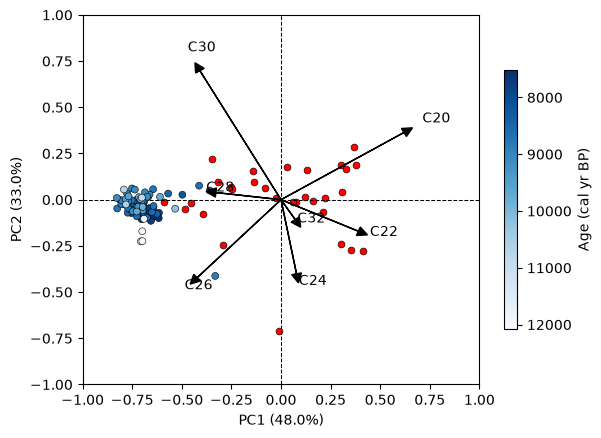

In [23]:
arcticplant_data_df = pd.read_csv(r'../leafwaxtools/data/Lindberg_Arctic_terrestrial_plantwaxes.csv')
cf8plant_data_df = arcticplant_data_df[arcticplant_data_df['site_name'] == "CF8"]
cf8plant_nacid_evenchain_df = cf8plant_data_df[
    [
        'c20_fconc',
        'c22_fconc',
        'c24_fconc',
        'c26_fconc',
        'c28_fconc',
        'c30_fconc',
        'c32_fconc'
    ]
]


cf8plant_nacid_evenchain_pca = Chain(cf8plant_nacid_evenchain_df).pca(
    chain_lengths=cf8_evenchain_lengths_str,
    drop_nans=True,
    supp_inds=cf8sed_nacid_evenchain_df
)


fig, ax = plt.subplots()

# Plot loading vectors (leaf wax chain-length variables)
for i, feature in enumerate(cf8plant_nacid_evenchain_pca["features"]):
    ax.arrow(
        0, 0, cf8plant_nacid_evenchain_pca["loadings"].iloc[i,0], cf8plant_nacid_evenchain_pca["loadings"].iloc[i,1],
        head_width=0.05, head_length=0.05, color='black', zorder=15
    )
    ax.text(
        cf8plant_nacid_evenchain_pca["loadings"].iloc[i,0] * 1.15, cf8plant_nacid_evenchain_pca["loadings"].iloc[i,1] * 1.15,
        str(feature), fontsize=10, zorder=15
    )

# Plot active sample (plants) principal component scores
sns.scatterplot(
    ax=ax, x=cf8plant_nacid_evenchain_pca["scores_scaled"].PC1, y=cf8plant_nacid_evenchain_pca["scores_scaled"].PC2,
    s=25, color='red', edgecolors='black', zorder=5
)

# Plot supplemental sample (sediments) principal component scores
sns.scatterplot(
    ax=ax, x=cf8plant_nacid_evenchain_pca["supp_inds_scores_scaled"].PC1, y=cf8plant_nacid_evenchain_pca["supp_inds_scores_scaled"].PC2,
    s=25, hue=cf8sed_data_df.ageMedian, palette='Blues_r', edgecolors='black',
    legend=False, zorder=10
)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.75, zorder=5)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.75, zorder=5)
ax.set_xlabel("PC1 (" + str(np.round(cf8plant_nacid_evenchain_pca["pca"].explained_variance_ratio_[0]*100, decimals=0)) + "%)")
ax.set_ylabel("PC2 (" + str(np.round(cf8plant_nacid_evenchain_pca["pca"].explained_variance_ratio_[1]*100, decimals=0)) + "%)")
ax.set_xlim([-1,1])
ax.set_ylim([-1,1])

norm = plt.Normalize(cf8sed_data_df['ageMedian'].min(), cf8sed_data_df['ageMedian'].max())
sm = plt.cm.ScalarMappable(cmap='Blues_r', norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, ax=ax,
    location='right', shrink=0.7, label="Age (cal yr BP)",
).ax.invert_yaxis()

plt.show()